In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import lightgbm as lgb
from lightgbm import LGBMClassifier

from sklearn.metrics import roc_auc_score

import optuna

import shap

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_parquet('../data/processed/model_ready_data.parquet')

x = df.drop(columns='target')
y = df['target']

In [30]:
unseen_df = pd.read_parquet("../data/processed/unseen_processed.parquet")

In [5]:
x_train_full, x_test, y_train_full, y_test = train_test_split(x, y, test_size=0.15, random_state=42, stratify=y)

x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, test_size=0.1, random_state=42, stratify=y_train_full)

In [ ]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 2000),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", -1, 15),
        "num_leaves": trial.suggest_int("num_leaves", 16, 256),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 200),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state": 42,
        "n_jobs": -1,
        "is_unbalance": True
    }

    model = LGBMClassifier(**params, verbosity=-1)
    
    model.fit(
        x_train, y_train,
        eval_set=[(x_val, y_val)],
        eval_metric="auc",
        callbacks=[lgb.early_stopping(stopping_rounds=50)]
    )
    
    preds = model.predict_proba(x_val)[:,1]
    return roc_auc_score(y_val, preds)

study = optuna.create_study(direction="maximize", study_name='LGBM')
study.optimize(objective, n_trials=50, show_progress_bar=True, n_jobs=-1, gc_after_trial=True)

print("\n\nBest LGBM Params:", study.best_params)
best_params = study.best_params

[I 2026-03-18 09:39:02,832] A new study created in memory with name: LGBM
Best trial: 3. Best value: 0.917255:   2%|▏         | 1/50 [00:10<08:31, 10.45s/it]

[I 2026-03-18 09:39:13,112] Trial 3 finished with value: 0.9172548746594155 and parameters: {'n_estimators': 286, 'learning_rate': 0.014001862766292422, 'max_depth': 4, 'num_leaves': 114, 'min_child_samples': 180, 'subsample': 0.7510310014708826, 'colsample_bytree': 0.899566534362882, 'reg_alpha': 1.162070909712726e-05, 'reg_lambda': 6.811621038380023e-06}. Best is trial 3 with value: 0.9172548746594155.


Best trial: 3. Best value: 0.917255:   4%|▍         | 2/50 [00:15<05:43,  7.15s/it]

[I 2026-03-18 09:39:17,967] Trial 7 finished with value: 0.8747765382956302 and parameters: {'n_estimators': 516, 'learning_rate': 0.005828437006398277, 'max_depth': 1, 'num_leaves': 198, 'min_child_samples': 28, 'subsample': 0.8943283080565348, 'colsample_bytree': 0.667618447221161, 'reg_alpha': 0.00032207429020069035, 'reg_lambda': 0.7650694458691019}. Best is trial 3 with value: 0.9172548746594155.


Best trial: 4. Best value: 0.934959:   6%|▌         | 3/50 [00:24<06:11,  7.90s/it]

[I 2026-03-18 09:39:26,774] Trial 4 finished with value: 0.9349594028644597 and parameters: {'n_estimators': 361, 'learning_rate': 0.016202662630281226, 'max_depth': 9, 'num_leaves': 117, 'min_child_samples': 54, 'subsample': 0.660328264108855, 'colsample_bytree': 0.9725725316060022, 'reg_alpha': 0.00038512808549024763, 'reg_lambda': 0.09313868008332256}. Best is trial 4 with value: 0.9349594028644597.


Best trial: 4. Best value: 0.934959:   6%|▌         | 3/50 [00:28<06:11,  7.90s/it]

[I 2026-03-18 09:39:30,850] Trial 5 finished with value: 0.9148550843339285 and parameters: {'n_estimators': 1039, 'learning_rate': 0.013528881060113457, 'max_depth': 2, 'num_leaves': 84, 'min_child_samples': 81, 'subsample': 0.9078911670310579, 'colsample_bytree': 0.7112165956195488, 'reg_alpha': 1.6684763590025783e-06, 'reg_lambda': 2.3775763773019962}. Best is trial 4 with value: 0.9349594028644597.


Best trial: 4. Best value: 0.934959:  10%|█         | 5/50 [00:32<04:12,  5.62s/it]

[I 2026-03-18 09:39:35,109] Trial 2 finished with value: 0.9275113164174051 and parameters: {'n_estimators': 971, 'learning_rate': 0.12760077050107507, 'max_depth': 5, 'num_leaves': 37, 'min_child_samples': 127, 'subsample': 0.779646693089709, 'colsample_bytree': 0.9362378225173886, 'reg_alpha': 0.00275475506124001, 'reg_lambda': 0.03272375363736627}. Best is trial 4 with value: 0.9349594028644597.


Best trial: 4. Best value: 0.934959:  12%|█▏        | 6/50 [00:42<05:13,  7.13s/it]

[I 2026-03-18 09:39:45,177] Trial 6 finished with value: 0.9312786323106241 and parameters: {'n_estimators': 1216, 'learning_rate': 0.014942609475025464, 'max_depth': 5, 'num_leaves': 58, 'min_child_samples': 135, 'subsample': 0.7398795789419582, 'colsample_bytree': 0.6110251923412312, 'reg_alpha': 1.1544317720180889e-05, 'reg_lambda': 0.019656706890135895}. Best is trial 4 with value: 0.9349594028644597.


Best trial: 4. Best value: 0.934959:  14%|█▍        | 7/50 [00:45<04:09,  5.81s/it]

[I 2026-03-18 09:39:48,278] Trial 9 finished with value: 0.9333579045653349 and parameters: {'n_estimators': 552, 'learning_rate': 0.03459053608257316, 'max_depth': 9, 'num_leaves': 130, 'min_child_samples': 77, 'subsample': 0.6301495161675432, 'colsample_bytree': 0.6083609466590358, 'reg_alpha': 9.613263915043498e-06, 'reg_lambda': 0.023922366204943004}. Best is trial 4 with value: 0.9349594028644597.


Best trial: 4. Best value: 0.934959:  14%|█▍        | 7/50 [00:45<04:09,  5.81s/it]

[I 2026-03-18 09:39:48,761] Trial 0 finished with value: 0.9307227764400108 and parameters: {'n_estimators': 1300, 'learning_rate': 0.044950296947711306, 'max_depth': 5, 'num_leaves': 87, 'min_child_samples': 174, 'subsample': 0.7089862034833839, 'colsample_bytree': 0.6862572770454258, 'reg_alpha': 0.0013888799898114106, 'reg_lambda': 1.648998646912896}. Best is trial 4 with value: 0.9349594028644597.


Best trial: 4. Best value: 0.934959:  18%|█▊        | 9/50 [01:02<05:27,  7.99s/it]

[I 2026-03-18 09:40:05,261] Trial 11 finished with value: 0.9320771973506753 and parameters: {'n_estimators': 421, 'learning_rate': 0.005439616123200016, 'max_depth': 9, 'num_leaves': 119, 'min_child_samples': 155, 'subsample': 0.8100945531793265, 'colsample_bytree': 0.816627692769093, 'reg_alpha': 5.408190751960028e-08, 'reg_lambda': 1.323891348445716e-05}. Best is trial 4 with value: 0.9349594028644597.


Best trial: 4. Best value: 0.934959:  20%|██        | 10/50 [01:06<04:30,  6.75s/it]

[I 2026-03-18 09:40:09,246] Trial 10 finished with value: 0.9268402487700732 and parameters: {'n_estimators': 1557, 'learning_rate': 0.026391562834055728, 'max_depth': 3, 'num_leaves': 56, 'min_child_samples': 130, 'subsample': 0.8188928016325089, 'colsample_bytree': 0.7736396108915118, 'reg_alpha': 7.816450894446286e-07, 'reg_lambda': 2.3642059182657056e-06}. Best is trial 4 with value: 0.9349594028644597.


Best trial: 4. Best value: 0.934959:  22%|██▏       | 11/50 [01:13<04:26,  6.84s/it]

[I 2026-03-18 09:40:16,294] Trial 12 finished with value: 0.9120452274477043 and parameters: {'n_estimators': 1690, 'learning_rate': 0.005734535327321334, 'max_depth': 2, 'num_leaves': 198, 'min_child_samples': 178, 'subsample': 0.8790181478327032, 'colsample_bytree': 0.9182267145343246, 'reg_alpha': 2.1876612287156038e-07, 'reg_lambda': 2.32888988351849}. Best is trial 4 with value: 0.9349594028644597.


Best trial: 4. Best value: 0.934959:  24%|██▍       | 12/50 [01:26<05:33,  8.78s/it]

[I 2026-03-18 09:40:29,527] Trial 16 finished with value: 0.9221889145521758 and parameters: {'n_estimators': 825, 'learning_rate': 0.009335605107671148, 'max_depth': 4, 'num_leaves': 65, 'min_child_samples': 33, 'subsample': 0.9235692395889852, 'colsample_bytree': 0.6207474152212357, 'reg_alpha': 0.0002065441762503134, 'reg_lambda': 2.314659316478766e-08}. Best is trial 4 with value: 0.9349594028644597.


Best trial: 4. Best value: 0.934959:  26%|██▌       | 13/50 [01:36<05:37,  9.13s/it]

[I 2026-03-18 09:40:39,448] Trial 15 finished with value: 0.9329841488252221 and parameters: {'n_estimators': 553, 'learning_rate': 0.009026646088517455, 'max_depth': 8, 'num_leaves': 138, 'min_child_samples': 88, 'subsample': 0.9678487307213088, 'colsample_bytree': 0.6041626905894552, 'reg_alpha': 6.964196476258892e-08, 'reg_lambda': 0.0008312087349115054}. Best is trial 4 with value: 0.9349594028644597.


Best trial: 4. Best value: 0.934959:  28%|██▊       | 14/50 [02:18<11:25, 19.05s/it]

[I 2026-03-18 09:41:21,429] Trial 1 finished with value: 0.9322647577549539 and parameters: {'n_estimators': 1392, 'learning_rate': 0.017588737853405013, 'max_depth': 11, 'num_leaves': 134, 'min_child_samples': 25, 'subsample': 0.8680821661750384, 'colsample_bytree': 0.8923236969773578, 'reg_alpha': 1.567240020271595, 'reg_lambda': 3.021188019900471e-07}. Best is trial 4 with value: 0.9349594028644597.


Best trial: 4. Best value: 0.934959:  30%|███       | 15/50 [02:27<09:18, 15.95s/it]

[I 2026-03-18 09:41:30,198] Trial 17 finished with value: 0.9240866327037639 and parameters: {'n_estimators': 1998, 'learning_rate': 0.2599749177711171, 'max_depth': 15, 'num_leaves': 186, 'min_child_samples': 19, 'subsample': 0.6018339520579901, 'colsample_bytree': 0.9722211981420704, 'reg_alpha': 1.0664581132254085, 'reg_lambda': 8.21479957709315e-08}. Best is trial 4 with value: 0.9349594028644597.


Best trial: 14. Best value: 0.935389:  32%|███▏      | 16/50 [02:29<06:35, 11.63s/it]

[I 2026-03-18 09:41:31,768] Trial 14 finished with value: 0.9353891264107982 and parameters: {'n_estimators': 794, 'learning_rate': 0.011066703925291561, 'max_depth': 13, 'num_leaves': 250, 'min_child_samples': 85, 'subsample': 0.6261160876573647, 'colsample_bytree': 0.7425863306809461, 'reg_alpha': 3.5734088780209625e-05, 'reg_lambda': 9.189688274537387e-05}. Best is trial 14 with value: 0.9353891264107982.


Best trial: 14. Best value: 0.935389:  34%|███▍      | 17/50 [02:34<05:26,  9.89s/it]

[I 2026-03-18 09:41:37,619] Trial 19 finished with value: 0.9289058703403388 and parameters: {'n_estimators': 623, 'learning_rate': 0.056103478319475285, 'max_depth': 14, 'num_leaves': 153, 'min_child_samples': 77, 'subsample': 0.6063738740799484, 'colsample_bytree': 0.8473499458310872, 'reg_alpha': 0.4470794912749168, 'reg_lambda': 0.005802221895450901}. Best is trial 14 with value: 0.9353891264107982.


Best trial: 14. Best value: 0.935389:  34%|███▍      | 17/50 [02:36<05:26,  9.89s/it]

[I 2026-03-18 09:41:39,495] Trial 13 finished with value: 0.9322087899487279 and parameters: {'n_estimators': 1486, 'learning_rate': 0.021038705493991974, 'max_depth': 14, 'num_leaves': 90, 'min_child_samples': 97, 'subsample': 0.9474043053951573, 'colsample_bytree': 0.792767663685763, 'reg_alpha': 0.0735606982789767, 'reg_lambda': 7.0803082967693e-05}. Best is trial 14 with value: 0.9353891264107982.


Best trial: 14. Best value: 0.935389:  36%|███▌      | 18/50 [02:39<04:00,  7.52s/it]

[I 2026-03-18 09:41:42,378] Trial 8 finished with value: 0.933798002631852 and parameters: {'n_estimators': 1927, 'learning_rate': 0.013506962424824808, 'max_depth': 10, 'num_leaves': 249, 'min_child_samples': 129, 'subsample': 0.9261436423815921, 'colsample_bytree': 0.9156076150978776, 'reg_alpha': 8.377144069319645, 'reg_lambda': 0.056082322445717016}. Best is trial 14 with value: 0.9353891264107982.


Best trial: 14. Best value: 0.935389:  40%|████      | 20/50 [03:03<05:45, 11.51s/it]

[I 2026-03-18 09:42:06,587] Trial 25 finished with value: 0.931264435598801 and parameters: {'n_estimators': 206, 'learning_rate': 0.08173444241683069, 'max_depth': 12, 'num_leaves': 246, 'min_child_samples': 49, 'subsample': 0.6665770617926172, 'colsample_bytree': 0.7546451978561206, 'reg_alpha': 0.016796718733909612, 'reg_lambda': 0.0007458966185429839}. Best is trial 14 with value: 0.9353891264107982.


Best trial: 14. Best value: 0.935389:  42%|████▏     | 21/50 [03:04<04:01,  8.31s/it]

[I 2026-03-18 09:42:07,417] Trial 18 finished with value: 0.9270551105432426 and parameters: {'n_estimators': 767, 'learning_rate': 0.06549523988053067, 'max_depth': 14, 'num_leaves': 166, 'min_child_samples': 68, 'subsample': 0.6070346510209039, 'colsample_bytree': 0.9863523370524983, 'reg_alpha': 0.48194015642495747, 'reg_lambda': 0.0032804957181948634}. Best is trial 14 with value: 0.9353891264107982.


Best trial: 14. Best value: 0.935389:  42%|████▏     | 21/50 [03:06<04:01,  8.31s/it]

[I 2026-03-18 09:42:09,119] Trial 24 finished with value: 0.9310293708126526 and parameters: {'n_estimators': 218, 'learning_rate': 0.08724901717428622, 'max_depth': 13, 'num_leaves': 239, 'min_child_samples': 50, 'subsample': 0.6711801599461218, 'colsample_bytree': 0.7535084540558671, 'reg_alpha': 0.02863954915314457, 'reg_lambda': 0.00014508478991263294}. Best is trial 14 with value: 0.9353891264107982.


Best trial: 14. Best value: 0.935389:  46%|████▌     | 23/50 [03:12<02:46,  6.17s/it]

[I 2026-03-18 09:42:14,931] Trial 20 finished with value: 0.9284065283033291 and parameters: {'n_estimators': 737, 'learning_rate': 0.05675920581534478, 'max_depth': 13, 'num_leaves': 163, 'min_child_samples': 69, 'subsample': 0.6052008881697113, 'colsample_bytree': 0.9923205388711941, 'reg_alpha': 0.07603807982485938, 'reg_lambda': 0.016741702705560878}. Best is trial 14 with value: 0.9353891264107982.


Best trial: 14. Best value: 0.935389:  48%|████▊     | 24/50 [03:55<07:31, 17.38s/it]

[I 2026-03-18 09:42:58,467] Trial 21 finished with value: 0.9264386456336922 and parameters: {'n_estimators': 737, 'learning_rate': 0.05867056912770509, 'max_depth': 15, 'num_leaves': 168, 'min_child_samples': 64, 'subsample': 0.606361250550487, 'colsample_bytree': 0.9730038827915705, 'reg_alpha': 0.05815878836480099, 'reg_lambda': 0.01355619088680601}. Best is trial 14 with value: 0.9353891264107982.


Best trial: 14. Best value: 0.935389:  50%|█████     | 25/50 [03:58<05:25, 13.02s/it]

[I 2026-03-18 09:43:01,315] Trial 22 finished with value: 0.928080822972464 and parameters: {'n_estimators': 754, 'learning_rate': 0.05628786782179848, 'max_depth': 12, 'num_leaves': 249, 'min_child_samples': 66, 'subsample': 0.6316703604648628, 'colsample_bytree': 0.8349383892175065, 'reg_alpha': 0.02406566458832856, 'reg_lambda': 0.020525244097397134}. Best is trial 14 with value: 0.9353891264107982.


Best trial: 14. Best value: 0.935389:  50%|█████     | 25/50 [04:21<05:25, 13.02s/it]

[I 2026-03-18 09:43:23,884] Trial 26 finished with value: 0.9232037064338405 and parameters: {'n_estimators': 765, 'learning_rate': 0.07697854787350178, 'max_depth': 12, 'num_leaves': 249, 'min_child_samples': 55, 'subsample': 0.6717932772474952, 'colsample_bytree': 0.7449620285369258, 'reg_alpha': 0.014718105529916224, 'reg_lambda': 0.0009752710377399108}. Best is trial 14 with value: 0.9353891264107982.


Best trial: 14. Best value: 0.935389:  54%|█████▍    | 27/50 [04:23<04:31, 11.79s/it]

[I 2026-03-18 09:43:26,103] Trial 23 finished with value: 0.9262355234491457 and parameters: {'n_estimators': 782, 'learning_rate': 0.06194363629176092, 'max_depth': 13, 'num_leaves': 251, 'min_child_samples': 58, 'subsample': 0.6700502993546394, 'colsample_bytree': 0.8279223632749055, 'reg_alpha': 0.041256213476742146, 'reg_lambda': 0.0002885664273495579}. Best is trial 14 with value: 0.9353891264107982.


Best trial: 14. Best value: 0.935389:  56%|█████▌    | 28/50 [04:54<06:28, 17.67s/it]

[I 2026-03-18 09:43:57,492] Trial 27 finished with value: 0.9348802288946767 and parameters: {'n_estimators': 764, 'learning_rate': 0.00979821994753703, 'max_depth': -1, 'num_leaves': 169, 'min_child_samples': 53, 'subsample': 0.6809481570337149, 'colsample_bytree': 0.9997596302313274, 'reg_alpha': 0.00011953940898349993, 'reg_lambda': 7.880139597011055e-05}. Best is trial 14 with value: 0.9353891264107982.


Best trial: 14. Best value: 0.935389:  56%|█████▌    | 28/50 [05:21<06:28, 17.67s/it]

[I 2026-03-18 09:44:24,391] Trial 30 finished with value: 0.935623099142191 and parameters: {'n_estimators': 1856, 'learning_rate': 0.009136287086557466, 'max_depth': 10, 'num_leaves': 225, 'min_child_samples': 113, 'subsample': 0.6623370832596276, 'colsample_bytree': 0.8532630207014781, 'reg_alpha': 6.008844672257734e-05, 'reg_lambda': 0.13950900346316036}. Best is trial 30 with value: 0.935623099142191.


Best trial: 30. Best value: 0.935623:  60%|██████    | 30/50 [05:44<07:03, 21.16s/it]

[I 2026-03-18 09:44:47,276] Trial 35 finished with value: 0.9337073620871351 and parameters: {'n_estimators': 929, 'learning_rate': 0.009070312311681997, 'max_depth': 7, 'num_leaves': 220, 'min_child_samples': 108, 'subsample': 0.6994413624502588, 'colsample_bytree': 0.9433723513337663, 'reg_alpha': 8.39125051547645e-05, 'reg_lambda': 0.3235858535193373}. Best is trial 30 with value: 0.935623099142191.


Best trial: 30. Best value: 0.935623:  62%|██████▏   | 31/50 [05:54<05:40, 17.91s/it]

[I 2026-03-18 09:44:57,586] Trial 29 finished with value: 0.9353735646305306 and parameters: {'n_estimators': 1973, 'learning_rate': 0.008986525109501368, 'max_depth': 11, 'num_leaves': 235, 'min_child_samples': 111, 'subsample': 0.6716336622765161, 'colsample_bytree': 0.8648683147501871, 'reg_alpha': 7.60159224011014, 'reg_lambda': 0.1958844224221366}. Best is trial 30 with value: 0.935623099142191.


Best trial: 30. Best value: 0.935623:  64%|██████▍   | 32/50 [05:57<03:56, 13.16s/it]

[I 2026-03-18 09:44:59,661] Trial 31 finished with value: 0.9355046112012056 and parameters: {'n_estimators': 1851, 'learning_rate': 0.008567466442010755, 'max_depth': 10, 'num_leaves': 223, 'min_child_samples': 112, 'subsample': 0.6685180857779692, 'colsample_bytree': 0.8576643281797931, 'reg_alpha': 7.389193796516303e-05, 'reg_lambda': 0.13291546214866914}. Best is trial 30 with value: 0.935623099142191.


Best trial: 30. Best value: 0.935623:  64%|██████▍   | 32/50 [06:06<03:56, 13.16s/it]

[I 2026-03-18 09:45:08,981] Trial 28 finished with value: 0.9347530045156465 and parameters: {'n_estimators': 1910, 'learning_rate': 0.010067100469207894, 'max_depth': 11, 'num_leaves': 254, 'min_child_samples': 115, 'subsample': 0.6647129278799081, 'colsample_bytree': 0.8605911446346559, 'reg_alpha': 6.392458659530281, 'reg_lambda': 0.11272010143910077}. Best is trial 30 with value: 0.935623099142191.


Best trial: 30. Best value: 0.935623:  68%|██████▊   | 34/50 [06:21<03:25, 12.85s/it]

[I 2026-03-18 09:45:23,820] Trial 36 finished with value: 0.9339923883783534 and parameters: {'n_estimators': 1222, 'learning_rate': 0.007535763174775649, 'max_depth': 7, 'num_leaves': 223, 'min_child_samples': 113, 'subsample': 0.7181845692231912, 'colsample_bytree': 0.8590554538995417, 'reg_alpha': 0.000912945999501692, 'reg_lambda': 0.5654939985934552}. Best is trial 30 with value: 0.935623099142191.


Best trial: 30. Best value: 0.935623:  68%|██████▊   | 34/50 [06:23<03:25, 12.85s/it]

[I 2026-03-18 09:45:26,624] Trial 32 finished with value: 0.9347759376655146 and parameters: {'n_estimators': 1925, 'learning_rate': 0.010193989141173984, 'max_depth': 10, 'num_leaves': 214, 'min_child_samples': 114, 'subsample': 0.998791853913084, 'colsample_bytree': 0.8664965440053908, 'reg_alpha': 9.845074449981952, 'reg_lambda': 0.19784241012632633}. Best is trial 30 with value: 0.935623099142191.


Best trial: 30. Best value: 0.935623:  72%|███████▏  | 36/50 [06:31<02:09,  9.27s/it]

[I 2026-03-18 09:45:34,597] Trial 33 finished with value: 0.935176994774518 and parameters: {'n_estimators': 1918, 'learning_rate': 0.009384436067944793, 'max_depth': 10, 'num_leaves': 222, 'min_child_samples': 106, 'subsample': 0.9963533700247921, 'colsample_bytree': 0.8653213780569355, 'reg_alpha': 4.323924336809827e-05, 'reg_lambda': 0.16840858569826062}. Best is trial 30 with value: 0.935623099142191.


Best trial: 30. Best value: 0.935623:  72%|███████▏  | 36/50 [06:45<02:09,  9.27s/it]

[I 2026-03-18 09:45:48,557] Trial 34 finished with value: 0.935462294079425 and parameters: {'n_estimators': 1888, 'learning_rate': 0.009218560126218156, 'max_depth': 10, 'num_leaves': 228, 'min_child_samples': 111, 'subsample': 0.6940895033340896, 'colsample_bytree': 0.8621135986108553, 'reg_alpha': 9.405435836533758, 'reg_lambda': 0.12905963383134988}. Best is trial 30 with value: 0.935623099142191.


Best trial: 30. Best value: 0.935623:  74%|███████▍  | 37/50 [06:47<02:18, 10.69s/it]

[I 2026-03-18 09:45:50,102] Trial 37 finished with value: 0.9315904139433552 and parameters: {'n_estimators': 1218, 'learning_rate': 0.032134745344942164, 'max_depth': 8, 'num_leaves': 224, 'min_child_samples': 111, 'subsample': 0.7340118099632851, 'colsample_bytree': 0.8803274898074944, 'reg_alpha': 0.0010174737462794409, 'reg_lambda': 0.17076473852239157}. Best is trial 30 with value: 0.935623099142191.


Best trial: 30. Best value: 0.935623:  76%|███████▌  | 38/50 [07:45<01:35,  7.95s/it]

[I 2026-03-18 09:46:48,570] Trial 38 finished with value: 0.9349288253313022 and parameters: {'n_estimators': 1805, 'learning_rate': 0.0072970243348944195, 'max_depth': 8, 'num_leaves': 224, 'min_child_samples': 111, 'subsample': 0.7164565912511242, 'colsample_bytree': 0.8699228439080381, 'reg_alpha': 0.003323575164016244, 'reg_lambda': 0.26439659781026625}. Best is trial 30 with value: 0.935623099142191.


Best trial: 30. Best value: 0.935623:  78%|███████▊  | 39/50 [08:06<04:14, 23.12s/it]

[I 2026-03-18 09:47:08,832] Trial 45 finished with value: 0.9322677609055319 and parameters: {'n_estimators': 1762, 'learning_rate': 0.020157756097980286, 'max_depth': 6, 'num_leaves': 205, 'min_child_samples': 145, 'subsample': 0.7833502198908174, 'colsample_bytree': 0.7080429933792379, 'reg_alpha': 0.0038073585040619474, 'reg_lambda': 7.284752853621441}. Best is trial 30 with value: 0.935623099142191.


Best trial: 30. Best value: 0.935623:  80%|████████  | 40/50 [08:14<03:42, 22.24s/it]

[I 2026-03-18 09:47:17,075] Trial 40 finished with value: 0.9356878033864617 and parameters: {'n_estimators': 1751, 'learning_rate': 0.006822386521665105, 'max_depth': 10, 'num_leaves': 222, 'min_child_samples': 149, 'subsample': 0.7201790537860044, 'colsample_bytree': 0.8772886555483798, 'reg_alpha': 0.0018455517702943994, 'reg_lambda': 9.041793152977643}. Best is trial 40 with value: 0.9356878033864617.


Best trial: 40. Best value: 0.935688:  82%|████████▏ | 41/50 [08:27<02:42, 18.05s/it]

[I 2026-03-18 09:47:29,991] Trial 44 finished with value: 0.9333565394968903 and parameters: {'n_estimators': 1739, 'learning_rate': 0.020070365714034276, 'max_depth': 8, 'num_leaves': 205, 'min_child_samples': 196, 'subsample': 0.7778443755646649, 'colsample_bytree': 0.805196847439686, 'reg_alpha': 0.0028465042304823994, 'reg_lambda': 8.182991969119202}. Best is trial 40 with value: 0.9356878033864617.


Best trial: 40. Best value: 0.935688:  84%|████████▍ | 42/50 [08:41<02:12, 16.52s/it]

[I 2026-03-18 09:47:44,522] Trial 39 finished with value: 0.9356760637978389 and parameters: {'n_estimators': 1794, 'learning_rate': 0.007389031057612419, 'max_depth': 11, 'num_leaves': 224, 'min_child_samples': 112, 'subsample': 0.7127757344763483, 'colsample_bytree': 0.8657346013518362, 'reg_alpha': 0.0018700125391830137, 'reg_lambda': 7.0136847030547145}. Best is trial 40 with value: 0.9356878033864617.


Best trial: 40. Best value: 0.935688:  86%|████████▌ | 43/50 [08:47<01:51, 15.90s/it]

[I 2026-03-18 09:47:49,887] Trial 42 finished with value: 0.9358076563958917 and parameters: {'n_estimators': 1697, 'learning_rate': 0.0072358302739767835, 'max_depth': 11, 'num_leaves': 233, 'min_child_samples': 148, 'subsample': 0.7713783238342277, 'colsample_bytree': 0.8870018180012867, 'reg_alpha': 3.416569469121969e-05, 'reg_lambda': 9.438094404304614}. Best is trial 42 with value: 0.9358076563958917.


Best trial: 42. Best value: 0.935808:  88%|████████▊ | 44/50 [08:50<01:16, 12.75s/it]

[I 2026-03-18 09:47:53,716] Trial 43 finished with value: 0.9319319540681771 and parameters: {'n_estimators': 1782, 'learning_rate': 0.021277479378393117, 'max_depth': 11, 'num_leaves': 230, 'min_child_samples': 149, 'subsample': 0.6392913514573496, 'colsample_bytree': 0.8892066390086144, 'reg_alpha': 3.968184249714054e-06, 'reg_lambda': 3.625262457291869}. Best is trial 42 with value: 0.9358076563958917.


Best trial: 42. Best value: 0.935808:  90%|█████████ | 45/50 [08:52<00:50, 10.10s/it]

[I 2026-03-18 09:47:55,424] Trial 41 finished with value: 0.9358453322849607 and parameters: {'n_estimators': 1742, 'learning_rate': 0.0070061645981807025, 'max_depth': 11, 'num_leaves': 228, 'min_child_samples': 144, 'subsample': 0.6342722975398078, 'colsample_bytree': 0.8757305958360728, 'reg_alpha': 4.68625862067651e-05, 'reg_lambda': 4.221078915184757}. Best is trial 41 with value: 0.9358453322849607.


Best trial: 41. Best value: 0.935845:  92%|█████████▏| 46/50 [09:03<00:30,  7.57s/it]

[I 2026-03-18 09:48:06,081] Trial 46 finished with value: 0.9333164064846211 and parameters: {'n_estimators': 1715, 'learning_rate': 0.01867738175382908, 'max_depth': 6, 'num_leaves': 200, 'min_child_samples': 148, 'subsample': 0.6433336054365947, 'colsample_bytree': 0.8011506914331864, 'reg_alpha': 4.477818617505237e-06, 'reg_lambda': 7.958701791639602}. Best is trial 41 with value: 0.9358453322849607.


Best trial: 41. Best value: 0.935845:  96%|█████████▌| 48/50 [09:42<00:35, 17.55s/it]

[I 2026-03-18 09:48:44,858] Trial 48 finished with value: 0.9348390038276521 and parameters: {'n_estimators': 1647, 'learning_rate': 0.012483704737468406, 'max_depth': 10, 'num_leaves': 234, 'min_child_samples': 163, 'subsample': 0.6379697456737194, 'colsample_bytree': 0.8984797868239975, 'reg_alpha': 2.1677118358501456e-05, 'reg_lambda': 9.8144472951338}. Best is trial 41 with value: 0.9358453322849607.


Best trial: 41. Best value: 0.935845:  96%|█████████▌| 48/50 [09:45<00:35, 17.55s/it]

[I 2026-03-18 09:48:48,093] Trial 49 finished with value: 0.9347753916381367 and parameters: {'n_estimators': 1594, 'learning_rate': 0.012516981978412823, 'max_depth': 11, 'num_leaves': 186, 'min_child_samples': 156, 'subsample': 0.6329893931772729, 'colsample_bytree': 0.8895892818961808, 'reg_alpha': 3.921357911409572e-06, 'reg_lambda': 1.073554495464796}. Best is trial 41 with value: 0.9358453322849607.


Best trial: 41. Best value: 0.935845: 100%|██████████| 50/50 [09:52<00:00, 11.85s/it]

[I 2026-03-18 09:48:55,347] Trial 47 finished with value: 0.9337963645497185 and parameters: {'n_estimators': 1648, 'learning_rate': 0.012670214730420461, 'max_depth': 11, 'num_leaves': 186, 'min_child_samples': 90, 'subsample': 0.6381046577770341, 'colsample_bytree': 0.8118062482846609, 'reg_alpha': 2.2460309164163227e-06, 'reg_lambda': 2.1432336722013842e-05}. Best is trial 41 with value: 0.9358453322849607.


Best LGBM Params: {'n_estimators': 1742, 'learning_rate': 0.0070061645981807025, 'max_depth': 11, 'num_leaves': 228, 'min_child_samples': 144, 'subsample': 0.6342722975398078, 'colsample_bytree': 0.8757305958360728, 'reg_alpha': 4.68625862067651e-05, 'reg_lambda': 4.221078915184757}


In [13]:
best_params

{'n_estimators': 1742,
 'learning_rate': 0.0070061645981807025,
 'max_depth': 11,
 'num_leaves': 228,
 'min_child_samples': 144,
 'subsample': 0.6342722975398078,
 'colsample_bytree': 0.8757305958360728,
 'reg_alpha': 4.68625862067651e-05,
 'reg_lambda': 4.221078915184757}

In [14]:
final_model = LGBMClassifier(**best_params, random_state=42, n_jobs=-1, is_unbalance=True, verbosity=-1)

In [15]:
final_model.fit(x_train_full, y_train_full)

,boosting_type,'gbdt'
,num_leaves,228
,max_depth,11
,learning_rate,0.0070061645981807025
,n_estimators,1742
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,144


In [16]:
y_pred = final_model.predict_proba(x_test)[:, 1]

print(roc_auc_score(y_test, y_pred))

0.9338480968251184


As we can see our model improved a little.

### Feature Importance

In [11]:
importance = pd.DataFrame({
    "feature": x_train_final.columns,
    "importance": final_model.feature_importances_
}).sort_values('importance', ascending=False)

importance.head(10)

,feature,importance
1,Age_Oldest_TL,10491
14,Time_With_Curr_Empr,10301
36,time_since_recent_payment,9927
35,time_since_recent_enq,9083
8,NETMONTHLYINCOME,8104
0,Age_Newest_TL,6118
19,max_recent_level_of_deliq,3541
24,num_std_12mts,3442
13,Secured_TL,3035
33,pct_tl_open_L6M,2877


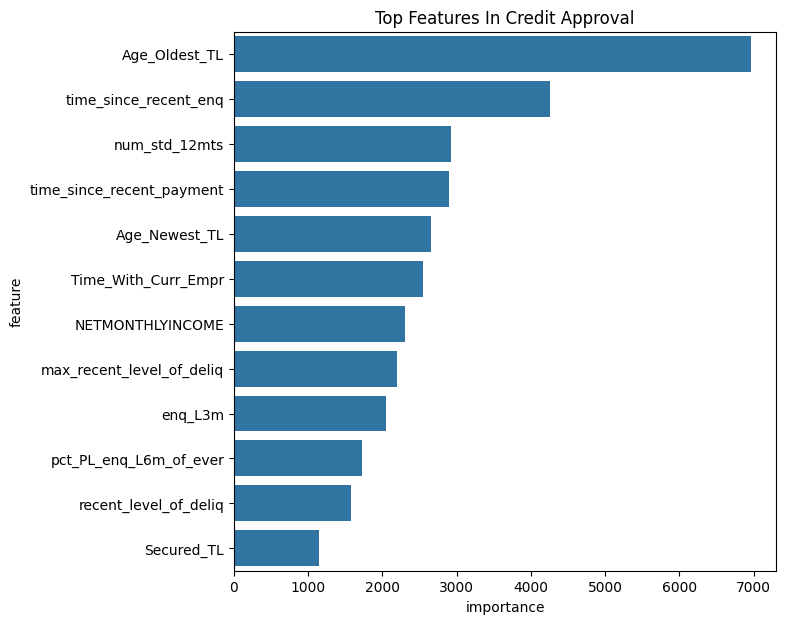

In [22]:
plt.figure(figsize=(7, 7))
sns.barplot(x='importance', y='feature', data=importance[importance['importance'] > 1000])
plt.title("Top Features In Credit Approval")
plt.show()

Above are the features which are helping in deciding the approval of client.

The most helping feature is `Age_Oldest_TL`, that is customer with older credit histories are more trustworthy because they have longer repayment records.

### SHAP

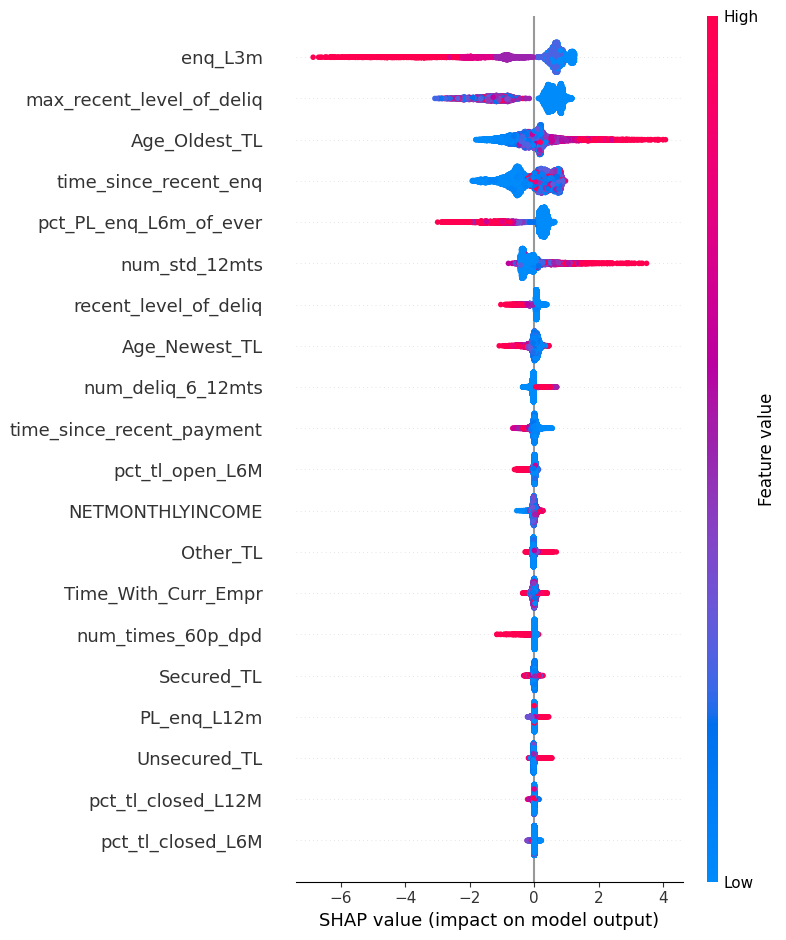

In [23]:
explainer = shap.TreeExplainer(final_model)

shap_values = explainer.shap_values(x_test)

shap.summary_plot(shap_values, x_test)

SHAP shows us even clearer picture.

It clearly shows how clients with most recent credit enquiries have lower chance of getting approved.

### Decision Thresholds

In [17]:
probas = final_model.predict_proba(x_test)[:, 1]

In [18]:
credit_score = 300 + probas * 600

In [26]:
def scores(score):
    if score >= 800:
        return "Very Safe"
    
    elif score >= 650:
        return "Safe"
    
    elif score >= 550:
        return "Moderate Risk"
    
    else: 
        return "High Risk"
    
    

def credit_decision(p):

    if p >= 0.8:
        return "Approve"
    
    elif p >= 0.6:
        return "Review"
    
    else:
        return "Reject"

In [27]:
results = x_test.copy()

results["actual"] = y_test
results["probabilty"] = probas
results["credit_score"] = credit_score
results['risk_band'] = results['credit_score'].apply(scores)
results['decision'] = results['probabilty'].apply(credit_decision)

results.head()

,Age_Newest_TL,Age_Oldest_TL,CC_Flag,CC_TL,CC_enq_L12m,GL_Flag,HL_Flag,Home_TL,NETMONTHLYINCOME,Other_TL,...,last_prod_enq2_CC,last_prod_enq2_ConsumerLoan,last_prod_enq2_HL,last_prod_enq2_PL,last_prod_enq2_others,actual,probabilty,credit_score,risk_band,decision
44828,17.0,81.0,0.0,0.0,0.0,0.0,0.0,0.0,22000.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1,0.223908,434.344510,High Risk,Reject
19040,4.0,14.0,0.0,0.0,0.0,0.0,0.0,0.0,39000.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1,0.428850,557.310177,Moderate Risk,Reject
5496,2.0,172.0,0.0,0.0,0.0,0.0,0.0,0.0,29000.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1,0.928773,857.263680,Very Safe,Approve
14496,7.0,49.0,0.0,0.0,0.0,0.0,0.0,0.0,30000.0,1.0,...,0.0,0.0,0.0,0.0,1.0,1,0.584624,650.774257,Safe,Reject
26246,5.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,30000.0,1.0,...,0.0,0.0,0.0,0.0,1.0,1,0.972108,883.264582,Very Safe,Approve


In [29]:
results['risk_band'].value_counts()

risk_band
Very Safe        4370
High Risk        2199
Moderate Risk     630
Safe              502
Name: count, dtype: int64

In [33]:
results.groupby('risk_band')['actual'].mean().sort_values(ascending=False)

risk_band
Very Safe        0.972082
Safe             0.848606
Moderate Risk    0.695238
High Risk        0.267849
Name: actual, dtype: float64

### Predicting on Unseen Dataset

In [31]:
unseen_proba = final_model.predict_proba(unseen_df)[:, 1]

unseen_df['credit_score'] = 300 + unseen_proba * 600
unseen_df['risk_band'] = unseen_df['credit_score'].apply(scores)
unseen_df['decision'] = [credit_decision(p) for p in unseen_proba]

In [32]:
unseen_df

,pct_tl_open_L6M,pct_tl_closed_L6M,Tot_TL_closed_L12M,pct_tl_closed_L12M,Tot_Missed_Pmnt,CC_TL,Home_TL,PL_TL,Secured_TL,Unsecured_TL,...,first_prod_enq2_PL,first_prod_enq2_others,last_prod_enq2_CC,last_prod_enq2_ConsumerLoan,last_prod_enq2_HL,last_prod_enq2_PL,last_prod_enq2_others,credit_score,risk_band,decision
0,0.000,0.0,0.0,0.000,0.0,0.0,0.0,4.0,1.0,4.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,724.735704,Safe,Review
1,0.000,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,436.412022,High Risk,Reject
2,0.125,0.0,0.0,0.000,1.0,0.0,0.0,0.0,2.0,6.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,740.881596,Safe,Review
3,0.000,0.0,0.0,0.000,0.0,0.0,0.0,0.0,3.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,491.971241,High Risk,Reject
4,0.000,0.0,1.0,0.167,0.0,0.0,0.0,0.0,6.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,700.509586,Safe,Review
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.000,0.0,0.0,0.000,0.0,0.0,0.0,1.0,1.0,5.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,774.310135,Safe,Review
96,0.222,0.0,2.0,0.222,0.0,0.0,0.0,0.0,1.0,8.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,440.683946,High Risk,Reject
97,0.000,0.0,0.0,0.000,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,449.275576,High Risk,Reject
98,0.000,1.0,1.0,1.000,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,451.070831,High Risk,Reject
